In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

In [5]:
#Preprocess+eda+feature sele tion
#1. extract input and output cols
#2.scale the values
#train test split
#4.train the model
#5. evaluate  the model/model selection
#6. deploy the modeeeel

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
df=df.iloc[:,1:]

In [10]:
df.head(

)

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [11]:
import matplotlib.pyplot as plt

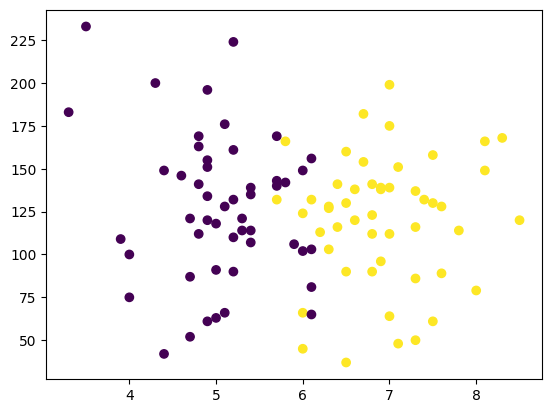

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [14]:
#logistic regression
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [15]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [18]:
X_train

,cgpa,iq
96,4.4,42.0
67,5.0,118.0
51,4.8,141.0
25,5.0,91.0
33,6.0,149.0
...,...,...
41,5.4,114.0
29,7.0,112.0
24,4.7,121.0
56,6.1,65.0


In [19]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [20]:
X_train

array([[-1.35159386, -2.06429036],
       [-0.83579126, -0.17460272],
       [-1.00772546,  0.39727644],
       [-0.83579126, -0.84593912],
       [ 0.02387975,  0.59619092],
       [-0.23402155,  1.09347715],
       [ 0.36774815, -0.22433134],
       [ 1.14145206, -0.97026067],
       [ 0.28178105,  0.04917608],
       [-1.17965966,  0.52159799],
       [ 0.96951786, -1.91510449],
       [ 0.88355076,  0.34754781],
       [ 1.39935336,  0.07404039],
       [-0.23402155,  0.44700506],
       [-0.14805445,  0.42214075],
       [ 1.14145206,  0.29781919],
       [ 0.10984685,  0.17349764],
       [-1.69546226, -0.62216032],
       [ 1.82918886,  0.59619092],
       [ 0.10984685,  0.7702411 ],
       [ 1.57128756, -0.27405996],
       [ 0.10984685, -0.54756738],
       [ 1.82918886,  1.01888421],
       [-2.12529776,  2.68479305],
       [ 0.45371525,  0.12376901],
       [-0.92175836,  0.22322626],
       [ 0.28178105,  0.07404039],
       [-0.66385705, -0.37351721],
       [-0.57788995,

In [22]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train,Y_train)

LogisticRegression()

In [27]:
y_pred=clf.predict(X_test)

In [25]:
Y_test

,placement
79,1
87,1
48,1
86,0
74,1
62,0
83,1
73,0
77,1
2,0


In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.8

<Axes: >

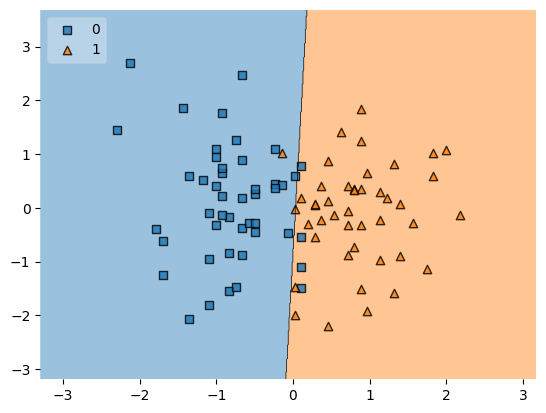

In [33]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [34]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))